# LSTM-Based Next Word Prediction System


In [9]:

# CELL 1: Install Dependencies

!pip install wikipedia tensorflow numpy scikit-learn matplotlib -q

In [11]:

# CELL 2: Imports

import wikipedia
import re
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Create output folders
os.makedirs('models', exist_ok=True)
print("Output folders ready")

TensorFlow version: 2.21.0
GPU available: False
Output folders ready


In [12]:

# CELL 3: Dataset Collection 

TOPICS = [
    # Core AI/ML
    "Artificial intelligence",
    "Machine learning",
    "Deep learning",
    "Natural language processing",
    "Neural network",
    "Supervised learning",
    "Unsupervised learning",
    "Reinforcement learning",
    "Computer vision",
    "Convolutional neural network",
    # CS & Math
    "Computer science",
    "Python programming language",
    "Data science",
    "Algorithm",
    "Statistics",
    "Linear algebra",
    "Probability theory",
    # Tech
    "Robotics",
    "Quantum computing",
    "Big data",
    "Data mining",
    "Information theory"
]

raw_texts = []
for topic in TOPICS:
    try:
        page = wikipedia.page(topic, auto_suggest=False)
        raw_texts.append(page.content)
        print(f" Fetched: {topic} ({len(page.content):,} chars)")
    except Exception as e:
        print(f" Skipped: {topic} — {e}")

full_corpus = " ".join(raw_texts)
print(f"\nTotal corpus size: {len(full_corpus):,} characters")

 Fetched: Artificial intelligence (84,284 chars)
 Fetched: Machine learning (59,410 chars)
 Fetched: Deep learning (56,562 chars)
 Fetched: Natural language processing (32,398 chars)
 Fetched: Neural network (5,336 chars)
 Fetched: Supervised learning (24,404 chars)
 Fetched: Unsupervised learning (15,778 chars)
 Fetched: Reinforcement learning (52,478 chars)
 Fetched: Computer vision (38,953 chars)
 Fetched: Convolutional neural network (66,228 chars)
 Fetched: Computer science (30,082 chars)
 Fetched: Python programming language (39,421 chars)
 Fetched: Data science (10,055 chars)
 Fetched: Algorithm (27,219 chars)
 Fetched: Statistics (46,873 chars)
 Fetched: Linear algebra (63,855 chars)
 Fetched: Probability theory (31,615 chars)
 Fetched: Robotics (33,204 chars)
 Fetched: Quantum computing (64,415 chars)
 Fetched: Big data (58,865 chars)
 Fetched: Data mining (22,855 chars)
 Fetched: Information theory (57,760 chars)

Total corpus size: 922,071 characters


In [13]:

# CELL 4: Data Preprocessing

def clean_text(text):
    text = text.lower()
    text = re.sub(r'==+.*?==+', '', text)        # Remove Wikipedia headers
    text = re.sub(r'http\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r"[^a-z\s]", '', text)          # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()      # Collapse spaces
    return text

cleaned_corpus = clean_text(full_corpus)
words = cleaned_corpus.split()

print(f"Total words after cleaning: {len(words):,}")
print(f"Sample: {' '.join(words[:50])}")

word_freq = Counter(words)
print(f"\nUnique words: {len(word_freq):,}")
print(f"Top 10 words: {word_freq.most_common(10)}")

Total words after cleaning: 119,049
Sample: artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problemsolving perception and decisionmaking it is a field of research in engineering mathematics and computer science that develops and studies methods and software that enable machines to perceive their

Unique words: 11,353
Top 10 words: [('the', 6383), ('of', 4193), ('and', 3296), ('a', 3023), ('to', 2801), ('in', 2549), ('is', 1965), ('that', 1246), ('for', 1200), ('data', 1088)]


In [14]:

# CELL 5: Tokenization & Sequence Generation

SEQ_LENGTH    = 5    # Shorter window = easier to learn patterns
MIN_WORD_FREQ = 3    # Filter rare words more aggressively

# Filter rare words
filtered_words = [w for w in words if word_freq[w] >= MIN_WORD_FREQ]
filtered_text  = ' '.join(filtered_words)

tokenizer = Tokenizer()
tokenizer.fit_on_texts([filtered_text])

VOCAB_SIZE = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {VOCAB_SIZE:,}")
print(f"Filtered words : {len(filtered_words):,}")

# Sliding window sequences
sequences  = []
token_list = tokenizer.texts_to_sequences([filtered_text])[0]

for i in range(SEQ_LENGTH, len(token_list)):
    seq = token_list[i - SEQ_LENGTH: i + 1]
    sequences.append(seq)

sequences = np.array(sequences)
print(f"Total sequences: {len(sequences):,}")
print(f"Sequence shape : {sequences.shape}")

Vocabulary size: 4,205
Filtered words : 110,135
Total sequences: 110,130
Sequence shape : (110130, 6)


In [15]:

# CELL 6: Prepare X and y  (sparse — no MemoryError)

X     = sequences[:, :-1]
y_raw = sequences[:, -1]   # Keep as integer indices — no one-hot encoding

X_train, X_val, y_train, y_val = train_test_split(
    X, y_raw, test_size=0.1, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_val  : {X_val.shape}")
print(f"y_train: {y_train.shape}  (integer class indices, not one-hot)")


X_train: (99117, 5)
X_val  : (11013, 5)
y_train: (99117,)  (integer class indices, not one-hot)


In [16]:

# CELL 7: Build Improved LSTM Model

EMBEDDING_DIM = 128
LSTM_UNITS_1  = 256
LSTM_UNITS_2  = 128
DROPOUT_RATE  = 0.3

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              input_length=SEQ_LENGTH,
              name='embedding'),

    LSTM(LSTM_UNITS_1, return_sequences=True, name='lstm_1'),
    Dropout(DROPOUT_RATE, name='dropout_1'),

    LSTM(LSTM_UNITS_2, return_sequences=False, name='lstm_2'),
    Dropout(DROPOUT_RATE, name='dropout_2'),

    Dense(VOCAB_SIZE, activation='softmax', name='output')
])

model.compile(
    loss='sparse_categorical_crossentropy',   # sparse: accepts integer labels directly
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


c:\Users\LENOVO\Downloads\LSTM\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:

# CELL 8: Train the Model 

EPOCHS     = 100  
BATCH_SIZE = 64    # Smaller batch = better gradient updates

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,                # Wait 8 epochs before stopping
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'models/best_lstm_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(             # Reduce learning rate when stuck
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!")

Epoch 1/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.0610 - loss: 6.8185
Epoch 1: val_loss improved from None to 6.43202, saving model to models/best_lstm_model.h5



Epoch 1: finished saving model to models/best_lstm_model.h5
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 204s 127ms/step - accuracy: 0.0682 - loss: 6.6166 - val_accuracy: 0.0777 - val_loss: 6.4320 - learning_rate: 0.0010
Epoch 2/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.0887 - loss: 6.2826
Epoch 2: val_loss improved from 6.43202 to 6.24797, saving model to models/best_lstm_model.h5



Epoch 2: finished saving model to models/best_lstm_model.h5
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 139s 86ms/step - accuracy: 0.0911 - loss: 6.2725 - val_accuracy: 0.0960 - val_loss: 6.2480 - learning_rate: 0.0010
Epoch 3/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1107 - loss: 6.0634
Epoch 3: val_loss improved from 6.24797 to 6.05198, saving model to models/best_lstm_model.h5



Epoch 3: finished saving model to models/best_lstm_model.h5
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 141s 85ms/step - accuracy: 0.1152 - loss: 6.0349 - val_accuracy: 0.1198 - val_loss: 6.0520 - learning_rate: 0.0010
Epoch 4/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.1317 - loss: 5.8280
Epoch 4: val_loss improved from 6.05198 to 5.93935, saving model to models/best_lstm_model.h5



Epoch 4: finished saving model to models/best_lstm_model.h5
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 136s 88ms/step - accuracy: 0.1324 - loss: 5.8184 - val_accuracy: 0.1282 - val_loss: 5.9393 - learning_rate: 0.0010
Epoch 5/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1461 - loss: 5.6374
Epoch 5: val_loss improved from 5.93935 to 5.86090, saving model to models/best_lstm_model.h5



Epoch 5: finished saving model to models/best_lstm_model.h5
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 121s 74ms/step - accuracy: 0.1439 - loss: 5.6467 - val_accuracy: 0.1386 - val_loss: 5.8609 - learning_rate: 0.0010
Epoch 6/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.1521 - loss: 5.4832
Epoch 6: val_loss improved from 5.86090 to 5.81862, saving model to models/best_lstm_model.h5



Epoch 6: finished saving model to models/best_lstm_model.h5
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 222s 125ms/step - accuracy: 0.1529 - loss: 5.4960 - val_accuracy: 0.1433 - val_loss: 5.8186 - learning_rate: 0.0010
Epoch 7/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.1617 - loss: 5.3375
Epoch 7: val_loss improved from 5.81862 to 5.81693, saving model to models/best_lstm_model.h5



Epoch 7: finished saving model to models/best_lstm_model.h5
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 166s 102ms/step - accuracy: 0.1600 - loss: 5.3599 - val_accuracy: 0.1463 - val_loss: 5.8169 - learning_rate: 0.0010
Epoch 8/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.1660 - loss: 5.2148
Epoch 8: val_loss improved from 5.81693 to 5.80790, saving model to models/best_lstm_model.h5



Epoch 8: finished saving model to models/best_lstm_model.h5
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 201s 101ms/step - accuracy: 0.1654 - loss: 5.2411 - val_accuracy: 0.1475 - val_loss: 5.8079 - learning_rate: 0.0010
Epoch 9/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.1729 - loss: 5.0958
Epoch 9: val_loss did not improve from 5.80790
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 211s 107ms/step - accuracy: 0.1712 - loss: 5.1233 - val_accuracy: 0.1503 - val_loss: 5.8251 - learning_rate: 0.0010
Epoch 10/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1772 - loss: 4.9769
Epoch 10: val_loss did not improve from 5.80790
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 163s 81ms/step - accuracy: 0.1760 - loss: 5.0164 - val_accuracy: 0.1496 - val_loss: 5.8544 - learning_rate: 0.0010
Epoch 11/100
1549/1549 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1843 - loss: 4.8637
Epoch 11: val_loss did not improve from 5.80790

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1549/

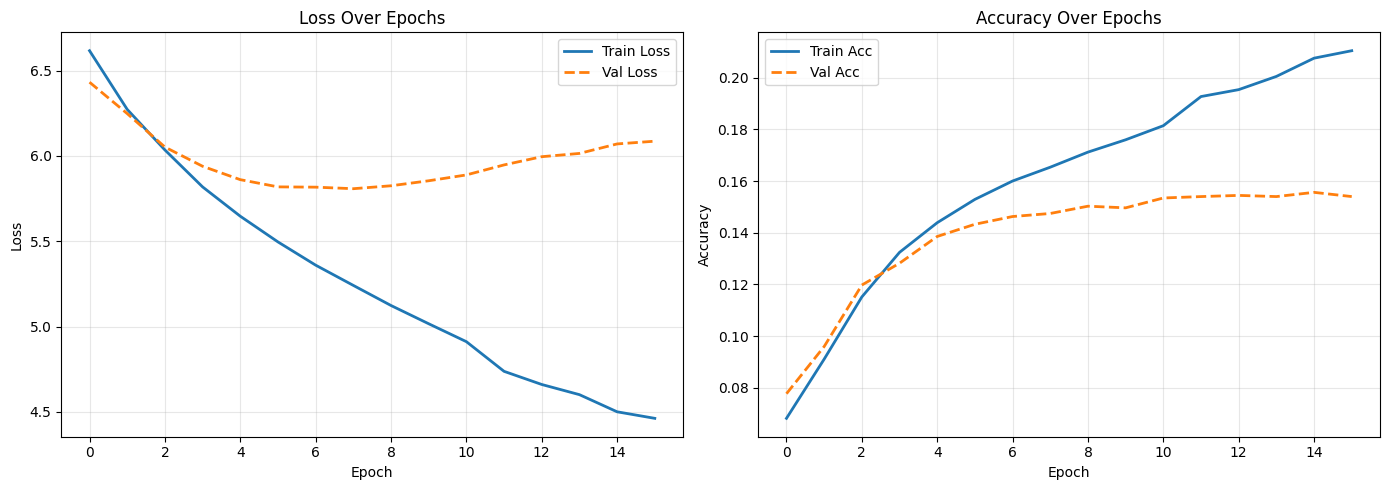

 Training curves saved.


In [18]:

# CELL 9: Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   linewidth=2, linestyle='--')
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print(" Training curves saved.")

In [19]:

# CELL 10: Prediction Functions

def predict_next_words(seed_text, n_words=5, temperature=0.5):
    result_text  = seed_text
    current_text = re.sub(r"[^a-z\s]", '', seed_text.lower()).strip()

    for _ in range(n_words):
        token_list  = tokenizer.texts_to_sequences([current_text])[0]
        token_list  = pad_sequences([token_list], maxlen=SEQ_LENGTH, padding='pre')
        predictions = model.predict(token_list, verbose=0)[0]

        # Temperature scaling
        predictions = np.log(predictions + 1e-8) / temperature
        predictions = np.exp(predictions) / np.sum(np.exp(predictions))

        predicted_index = np.random.choice(len(predictions), p=predictions)
        predicted_word  = next(
            (w for w, i in tokenizer.word_index.items() if i == predicted_index), ""
        )
        if predicted_word:
            result_text  += " " + predicted_word
            current_text += " " + predicted_word

    return result_text


def predict_top_k(seed_text, k=5):
    current_text = re.sub(r"[^a-z\s]", '', seed_text.lower()).strip()
    token_list   = tokenizer.texts_to_sequences([current_text])[0]
    token_list   = pad_sequences([token_list], maxlen=SEQ_LENGTH, padding='pre')
    predictions  = model.predict(token_list, verbose=0)[0]

    top_k_indices = np.argsort(predictions)[-k:][::-1]
    index_to_word = {v: k for k, v in tokenizer.word_index.items()}

    return [
        {"word": index_to_word.get(int(i), '<UNK>'), "probability": round(float(predictions[i]), 4)}
        for i in top_k_indices
    ]

print("Prediction functions ready")

Prediction functions ready


In [20]:

# CELL 11: Test Predictions

test_seeds = [
    "machine learning is",
    "artificial intelligence can",
    "deep learning uses neural",
    "the algorithm is used",
    "natural language processing"
]

print("=" * 60)
print("LSTM NEXT WORD PREDICTION — RESULTS")
print("=" * 60)

for seed in test_seeds:
    predicted = predict_next_words(seed, n_words=5, temperature=0.5)
    top5      = predict_top_k(seed, k=5)

    print(f"\nSeed : '{seed}'")
    print(f"Output: '{predicted}'")
    print(f"Top-5 next words:")
    for item in top5:
        bar = '█' * int(item['probability'] * 50)
        print(f"   {item['word']:20s} {item['probability']:.4f}  {bar}")
    print("-" * 60)

LSTM NEXT WORD PREDICTION — RESULTS

Seed : 'machine learning is'
Output: 'machine learning is the brain for data the'
Top-5 next words:
   a                    0.1937  █████████
   the                  0.1200  ██████
   an                   0.0530  ██
   also                 0.0266  █
   used                 0.0256  █
------------------------------------------------------------

Seed : 'artificial intelligence can'
Output: 'artificial intelligence can be used to be explored'
Top-5 next words:
   be                   0.3670  ██████████████████
   also                 0.0473  ██
   have                 0.0195  
   not                  0.0195  
   the                  0.0161  
------------------------------------------------------------

Seed : 'deep learning uses neural'
Output: 'deep learning uses neural networks and the agent is'
Top-5 next words:
   networks             0.7570  █████████████████████████████████████
   neural               0.0412  ██
   network              0.0248  █


In [21]:

# CELL 12: Save All Files (Correct Locations for app.py)

# Save model inside models/
model.save('models/best_lstm_model.h5')
print(" Model saved: models/best_lstm_model.h5")

# Save tokenizer inside models/
with open('models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved: models/tokenizer.pkl")

# Save config in root (app.py looks here)
config = {
    'seq_length' : SEQ_LENGTH,
    'vocab_size' : VOCAB_SIZE,
    'embed_dim'  : EMBEDDING_DIM,
    'lstm1'      : LSTM_UNITS_1,
    'lstm2'      : LSTM_UNITS_2,
    'dropout'    : DROPOUT_RATE
}
with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("Config saved: model_config.pkl")

print("\n All files saved! Restart uvicorn to load new model.")
print("   Run: uvicorn app:app --reload --host 0.0.0.0 --port 8000")

 Model saved: models/best_lstm_model.h5
Tokenizer saved: models/tokenizer.pkl
Config saved: model_config.pkl

 All files saved! Restart uvicorn to load new model.
   Run: uvicorn app:app --reload --host 0.0.0.0 --port 8000


In [23]:
import pickle
with open("models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [22]:
import os
os.makedirs("models", exist_ok=True)

# Save the best model (already saved by ModelCheckpoint)
# Optionally save the final trained model too
model.save("models/lstm_model_final.h5")
print("Model saved ✓")

Model saved ✓
